For this example we use Mammographic Mass dataset.

https://archive.ics.uci.edu/dataset/161/mammographic+mass

Discrimination of benign and malignant mammographic masses based on BI-RADS attributes and the patient's age.

# Environment


For this project, you can create a Python environment either with **`.venv`** or with **Conda**.

## Option 1: Create an environment with `.venv`

```bash
python -m venv .venv

.venv/bin/activate
```

## Option 2: Create an environment with Conda

You can create a Conda environment either from the command line or with Anaconda Navigator.

Using the command line


```bash
conda create -n my-env
conda activate my-env

```

Alternatively you cane use the Anaconda Navigator

# Imports
We use the following cell to import all required libraries. This cell is extended iteratively as the codebase grows.

In [ ]:
from ucimlrepo import fetch_ucirepo # for Downloading datasets from UCI Machine Learning Repository
import pandas as pd # for data manipulation and analysis
import matplotlib.pyplot as plt # for data visualization
from sklearn.model_selection import train_test_split # for splitting the dataset into training and testing sets
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler # Encoding the Categorical Values and Scaling
from imblearn.over_sampling import SMOTENC, RandomOverSampler # for oversampling
from imblearn.under_sampling import RandomUnderSampler, TomekLinks # for undersampling
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay # Evaluation Metrics


# Load Data

There are two possible ways. Either Download the dataset and save it somewhere. Or use a library (pip install ucimlrepo) to download it directly. More Information for the direct method can be find on the website. 

## Option 1 
This is the most straightforward way to use this dataset. However, not every dataset provides such a simple structure or direct usability.

In [347]:
# fetch dataset 
mammographic_mass = fetch_ucirepo(id=161) 
  
# data (as pandas dataframes) 
X = mammographic_mass.data.features 
y = mammographic_mass.data.targets 
  
# metadata 
print("Metadata of mammographic_mass: \n", mammographic_mass.metadata) 
  
# variable information 
print("Variable information of mammographic_mass:  \n", mammographic_mass.variables) 


Metadata of mammographic_mass: 
 {'uci_id': 161, 'name': 'Mammographic Mass', 'repository_url': 'https://archive.ics.uci.edu/dataset/161/mammographic+mass', 'data_url': 'https://archive.ics.uci.edu/static/public/161/data.csv', 'abstract': "Discrimination of benign and malignant mammographic masses based on BI-RADS attributes and the patient's age.", 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 961, 'num_features': 5, 'feature_types': ['Integer'], 'demographics': ['Age'], 'target_col': ['Severity'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2007, 'last_updated': 'Thu Mar 28 2024', 'dataset_doi': '10.24432/C53K6Z', 'creators': ['Matthias Elter'], 'intro_paper': {'ID': 448, 'type': 'NATIVE', 'title': 'The prediction of breast cancer biopsy outcomes using two CAD approaches that both emphasize an intelligible decision process.', 'authors': 'M. Elter, R. Sch

Since "BI-RADS" is a non predictive attribute (see Website), we drop that Feature

In [348]:
X = X.drop(columns="BI-RADS") # drop the 'BI-RADS' column from the features

## Option 2

Since the downloaded file does not include a header row, we need to assign the column names ourselves based on the information provided on the website. Missing values are marked with ?, so we also need to convert them to NaN.

In [349]:
columns = ["BI-RADS", "Age", "Shape", "Margin", "Density", "Severity"]

df = pd.read_csv(
    "Datasets/mammographic+mass/mammographic_masses.data",
    header=None,
    names=columns,
    na_values="?"
)

X = df.drop(columns=["Severity", "BI-RADS"]) # drop the 'Severity' and 'BI-RADS' columns from the features
y = df["Severity"]

# Data Insights

## Shape

In [350]:
X.shape, y.shape

((961, 4), (961,))

## Info (Overview)

In [351]:
X.info()
print("---------------------------------------")
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 961 entries, 0 to 960
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Age      956 non-null    float64
 1   Shape    930 non-null    float64
 2   Margin   913 non-null    float64
 3   Density  885 non-null    float64
dtypes: float64(4)
memory usage: 30.2 KB
---------------------------------------
<class 'pandas.Series'>
RangeIndex: 961 entries, 0 to 960
Series name: Severity
Non-Null Count  Dtype
--------------  -----
961 non-null    int64
dtypes: int64(1)
memory usage: 7.6 KB


In [352]:
X.describe()

,Age,Shape,Margin,Density
count,956.000000,930.000000,913.000000,885.000000
mean,55.487448,2.721505,2.796276,2.910734
std,14.480131,1.242792,1.566546,0.380444
min,18.000000,1.000000,1.000000,1.000000
25%,45.000000,2.000000,1.000000,3.000000
50%,57.000000,3.000000,3.000000,3.000000
75%,66.000000,4.000000,4.000000,3.000000
max,96.000000,4.000000,5.000000,4.000000


To better understand the distribution of values in each feature, we inspect the value counts for all columns, including missing values.

In [353]:
for col in X.columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: Age
Age
59.0    36
67.0    32
57.0    32
66.0    31
46.0    28
        ..
18.0     1
82.0     1
93.0     1
96.0     1
20.0     1
Name: count, Length: 74, dtype: int64

Column: Shape
Shape
4.0    400
1.0    224
2.0    211
3.0     95
NaN     31
Name: count, dtype: int64

Column: Margin
Margin
1.0    357
4.0    280
5.0    136
3.0    116
NaN     48
2.0     24
Name: count, dtype: int64

Column: Density
Density
3.0    798
NaN     76
2.0     59
1.0     16
4.0     12
Name: count, dtype: int64


## Missing Value Count

In [354]:
print(X.isna().sum())
print("---------------------------------------")
print(y.isna().sum())

Age         5
Shape      31
Margin     48
Density    76
dtype: int64
---------------------------------------
0


## Target Distribution

In [355]:
print(y.value_counts())
print(y.value_counts(normalize=True))

Severity
0    516
1    445
Name: count, dtype: int64
Severity
0    0.536941
1    0.463059
Name: proportion, dtype: float64


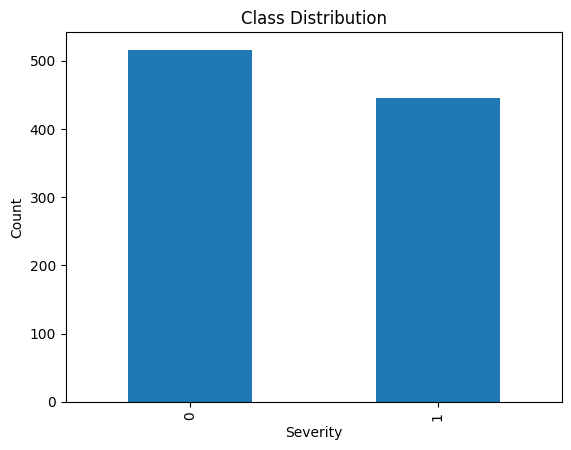

In [356]:
y.value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

# Target Encoding

In our dataset, the target variable "Severity" is already available in encoded form. For demonstration purposes, we convert it into string labels first, so we can show how a target variable can be encoded again.

In [357]:
y = y.map({0: "benign", 1: "malignant"}) # Encoding into string labels for demonstration purpose.
y

0      malignant
1      malignant
2      malignant
3         benign
4      malignant
         ...    
956       benign
957    malignant
958       benign
959    malignant
960       benign
Name: Severity, Length: 961, dtype: str

## Option 1
To encode the target we can use the python function "map".

In [358]:
y = y.map({"benign": 0, "malignant": 1})
y

0      1
1      1
2      1
3      0
4      1
      ..
956    0
957    1
958    0
959    1
960    0
Name: Severity, Length: 961, dtype: int64

## Option 2
Alternatively, we can use LabelEncoder from sklearn, which is especially useful when the target variable contains many classes.

In [359]:
le = LabelEncoder()
y = pd.Series(
    le.fit_transform(y),
    index=y.index,
    name="Severity"
)
y

0      1
1      1
2      1
3      0
4      1
      ..
956    0
957    1
958    0
959    1
960    0
Name: Severity, Length: 961, dtype: int64

# Dataset Split

In [360]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [361]:
print("y value counts normalized: \n", y.value_counts(normalize=True))
print("---------------------------------------")
print("y_train value counts normalized: \n", y_train.value_counts(normalize=True))
print("---------------------------------------")
print("---------------------------------------")
print("y_test value counts normalized: \n", y_test.value_counts(normalize=True))

y value counts normalized: 
 Severity
0    0.536941
1    0.463059
Name: proportion, dtype: float64
---------------------------------------
y_train value counts normalized: 
 Severity
0    0.536458
1    0.463542
Name: proportion, dtype: float64
---------------------------------------
---------------------------------------
y_test value counts normalized: 
 Severity
0    0.53886
1    0.46114
Name: proportion, dtype: float64


# Missing Values

In [362]:
print(X.isna().sum())
print("---------------------------------------")
print(y.isna().sum())

Age         5
Shape      31
Margin     48
Density    76
dtype: int64
---------------------------------------
0


## Age

In [363]:
X_train["Age"].value_counts(dropna=False).sort_index()

Age
18.0    1
19.0    3
20.0    1
21.0    6
22.0    2
       ..
87.0    4
88.0    1
93.0    1
96.0    1
NaN     3
Name: count, Length: 73, dtype: int64

In [364]:
print("Mean: ", round(X_train['Age'].mean()))
print("Median: ",X_train['Age'].median())
print("Mode: ", X_train['Age'].mode())

Mean:  55
Median:  56.0
Mode:  0    59.0
Name: Age, dtype: float64


In [365]:
X_train['Age']=X_train['Age'].fillna(round(X_train['Age'].mean()))
X_test['Age']=X_test['Age'].fillna(round(X_train['Age'].mean()))

## Shape

In [366]:
X_train["Shape"].value_counts(dropna=False).sort_index()

Shape
1.0    186
2.0    169
3.0     72
4.0    312
NaN     29
Name: count, dtype: int64

In [367]:
print("Mean: ", round(X_train['Shape'].mean()))
print("Median: ",X_train['Shape'].median())
print("Mode: ", X_train['Shape'].mode().iloc[0])

Mean:  3
Median:  3.0
Mode:  4.0


In [368]:
X_train['Shape']=X_train['Shape'].fillna(X_train['Shape'].mode().iloc[0])
X_test['Shape']=X_test['Shape'].fillna(X_train['Shape'].mode().iloc[0])

## Margin     

In [369]:
X_train["Margin"].value_counts(dropna=False).sort_index()

Margin
1.0    295
2.0     15
3.0     88
4.0    226
5.0    107
NaN     37
Name: count, dtype: int64

In [370]:
print("Mean: ", round(X_train['Margin'].mean()))
print("Median: ",X_train['Margin'].median())
print("Mode: ", X_train['Margin'].mode().iloc[0])

Mean:  3
Median:  3.0
Mode:  1.0


In [371]:
X_train['Margin']=X_train['Margin'].fillna(X_train['Margin'].mode().iloc[0])
X_test['Margin']=X_test['Margin'].fillna(X_train['Margin'].mode().iloc[0])

## Density    

In [372]:
X_train["Density"].value_counts(dropna=False).sort_index()

Density
1.0     11
2.0     45
3.0    641
4.0      9
NaN     62
Name: count, dtype: int64

In [373]:
print("Mean: ", round(X_train['Density'].mean()))
print("Median: ",X_train['Density'].median())
print("Mode: ", X_train['Density'].mode().iloc[0])

Mean:  3
Median:  3.0
Mode:  3.0


In [374]:
X_train['Density']=X_train['Density'].fillna(X_train['Density'].mode().iloc[0])
X_test['Density']=X_test['Density'].fillna(X_train['Density'].mode().iloc[0])

# Handling Outliers

Since most of the Features are Categorical, outliers can´t really appear. Only Age might be relevant for outlier handling. Therefore we check for anomalies, and looking vor Outliers via IQR.

## Anomalies

In [375]:
print(X_train["Age"].describe())
print(X_train["Age"].min(), df["Age"].max())

count    768.000000
mean      55.260417
std       14.742373
min       18.000000
25%       45.000000
50%       56.000000
75%       66.000000
max       96.000000
Name: Age, dtype: float64
18.0 96.0


## IQR-Methode

In our case there are no outlier. If you wanna see what happens if we find outlier and use Capping / Winsorizing, use 0.30 & 0.70 for the quantiles to create arround 24 outliers.

In [376]:
Q1 = X_train["Age"].quantile(0.25)
Q3 = X_train["Age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_age = X_train[(X_train["Age"] < lower_bound) | (X_train["Age"] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", outliers_age.shape[0])


Lower bound: 13.5
Upper bound: 97.5
Number of outliers: 0


## Capping / Winsorizing

In [377]:
X_train['Age'] = X_train["Age"].clip(lower=lower_bound, upper=upper_bound)
X_train['Age'].value_counts().sort_index()


Age
18.0    1
19.0    3
20.0    1
21.0    6
22.0    2
       ..
86.0    5
87.0    4
88.0    1
93.0    1
96.0    1
Name: count, Length: 72, dtype: int64

# Categorical Encoding

Since these features were already numerically encoded, applying an additional ordinal encoding step was not strictly necessary. In this case, changing the category range from starting at 1 to starting at 0 does not materially change the information content.

In [378]:
X_train

,Age,Shape,Margin,Density
441,56.0,2.0,3.0,3.0
626,79.0,4.0,4.0,3.0
796,58.0,4.0,4.0,2.0
287,39.0,4.0,3.0,3.0
193,41.0,1.0,1.0,3.0
...,...,...,...,...
704,60.0,1.0,1.0,3.0
105,54.0,1.0,1.0,3.0
508,71.0,4.0,5.0,3.0
464,50.0,2.0,1.0,3.0


In [379]:

categorical_cols = ["Shape", "Margin", "Density"]

encoder = OrdinalEncoder()

X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])




In [380]:
X_train

,Age,Shape,Margin,Density
441,56.0,1.0,2.0,2.0
626,79.0,3.0,3.0,2.0
796,58.0,3.0,3.0,1.0
287,39.0,3.0,2.0,2.0
193,41.0,0.0,0.0,2.0
...,...,...,...,...
704,60.0,0.0,0.0,2.0
105,54.0,0.0,0.0,2.0
508,71.0,3.0,4.0,2.0
464,50.0,1.0,0.0,2.0


# Scaling
For the numerical feature Age, we apply standardization rather than normalization. Standardization is often preferred for models such as logistic regression because it centers the data around zero and scales it to unit variance, while normalization mainly rescales values to a fixed range and is more sensitive to outliers.

In [381]:
scaler = StandardScaler()

X_train["Age"] = scaler.fit_transform(X_train[["Age"]])
X_test["Age"] = scaler.transform(X_test[["Age"]])

X_train

,Age,Shape,Margin,Density
441,0.050200,1.0,2.0,2.0
626,1.611345,3.0,3.0,2.0
796,0.185952,3.0,3.0,1.0
287,-1.103690,3.0,2.0,2.0
193,-0.967938,0.0,0.0,2.0
...,...,...,...,...
704,0.321703,0.0,0.0,2.0
105,-0.085552,0.0,0.0,2.0
508,1.068338,3.0,4.0,2.0
464,-0.357055,1.0,0.0,2.0


# Over- / Undersampling

In [382]:
smote_nc = SMOTENC(categorical_features=[1, 2, 3], random_state=42)
X_train_smote, y_train_smote = smote_nc.fit_resample(X_train, y_train)

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print('Unbalanced')
print(y_train.value_counts())
print('\n SMOTE')
print(y_train_smote.value_counts())
print('\n RandomOversampler')
print(y_train_ros.value_counts())

Unbalanced
Severity
0    412
1    356
Name: count, dtype: int64

 SMOTE
Severity
1    412
0    412
Name: count, dtype: int64

 RandomOversampler
Severity
1    412
0    412
Name: count, dtype: int64


In [383]:
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

tomek = TomekLinks()
X_train_tomek, y_train_tomek = tomek.fit_resample(X_train, y_train)

print("Unbalanced")
print(y_train.value_counts())

print("\nRandomUnderSampler")
print(y_train_rus.value_counts())

print("\nTomekLinks")
print(y_train_tomek.value_counts())

Unbalanced
Severity
0    412
1    356
Name: count, dtype: int64

RandomUnderSampler
Severity
0    356
1    356
Name: count, dtype: int64

TomekLinks
Severity
0    392
1    356
Name: count, dtype: int64


To make the comparison of different data subsets easier, we store them in a dictionary and access them later during model training and evaluation.

In [384]:
datasets = {
    "unbalanced": (X_train, y_train),
    "smote": (X_train_smote, y_train_smote),
    "ros": (X_train_ros, y_train_ros),
    "rus": (X_train_rus, y_train_rus),
    "tomek": (X_train_tomek, y_train_tomek)
}

# Modelling

For demonstration purposes we use two basic models without any Hyperparameter tuning. Feel free to test around, to get better results.

## Random Forest

In [385]:
rf_models = {}

for name, (X_data, y_data) in datasets.items():
    model = RandomForestClassifier(
    n_estimators=100,       # Number of trees in the forest
                            # Try: 50, 100, 200

    max_depth=None,         # Maximum depth of each tree
                            # Try: None, 5, 10

    min_samples_split=2,    # Minimum number of samples needed to split a node
                            # Try: 2, 5, 10

    min_samples_leaf=1,     # Minimum number of samples required in a leaf
                            # Try: 1, 2, 4

    random_state=42         # Ensures reproducible results
)
    model.fit(X_data, y_data)
    rf_models[name] = model

rf_models

{'unbalanced': RandomForestClassifier(random_state=42),
 'smote': RandomForestClassifier(random_state=42),
 'ros': RandomForestClassifier(random_state=42),
 'rus': RandomForestClassifier(random_state=42),
 'tomek': RandomForestClassifier(random_state=42)}

## Multi-Layer-Perceptron (MLP)

In [386]:
mlp_models = {}

for name, (X_data, y_data) in datasets.items():
    model = MLPClassifier(
        hidden_layer_sizes=(50,),   # One hidden layer with 50 neurons
                                    # Try: (10,), (50,), (100,), (50, 50)

        activation="relu",          # Activation function
                                    # Try: "relu", "tanh", "logistic"

        solver="adam",              # Optimizer
                                    # Good default choice for many problems
                                    # Try: "adam", "lbfgs"

        alpha=0.0001,               # Regularization strength
                                    # Try: 0.0001, 0.001, 0.01

        max_iter=1000,              # Maximum number of training iterations
                                    # Increase if the model does not converge

        random_state=42             # Ensures reproducible results
    )

    model.fit(X_data, y_data)
    mlp_models[name] = model

mlp_models

{'unbalanced': MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42),
 'smote': MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42),
 'ros': MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42),
 'rus': MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42),
 'tomek': MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)}

# Testing

In [387]:
results = []

for name, model in rf_models.items():
    y_pred = model.predict(X_test)
    results.append({
        "model": "Random Forest",
        "dataset": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0)
    })

for name, model in mlp_models.items():
    y_pred = model.predict(X_test)
    results.append({
        "model": "MLP",
        "dataset": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df

,model,dataset,accuracy,precision,recall,f1
0,Random Forest,unbalanced,0.756477,0.701923,0.820225,0.756477
1,Random Forest,smote,0.761658,0.708738,0.820225,0.760417
2,Random Forest,ros,0.756477,0.701923,0.820225,0.756477
3,Random Forest,rus,0.751295,0.695238,0.820225,0.752577
4,Random Forest,tomek,0.751295,0.695238,0.820225,0.752577
5,MLP,unbalanced,0.803109,0.738318,0.887640,0.806122
6,MLP,smote,0.792746,0.724771,0.887640,0.797980
7,MLP,ros,0.792746,0.724771,0.887640,0.797980
8,MLP,rus,0.797927,0.731481,0.887640,0.802030
9,MLP,tomek,0.787565,0.718182,0.887640,0.793970


## Visualization

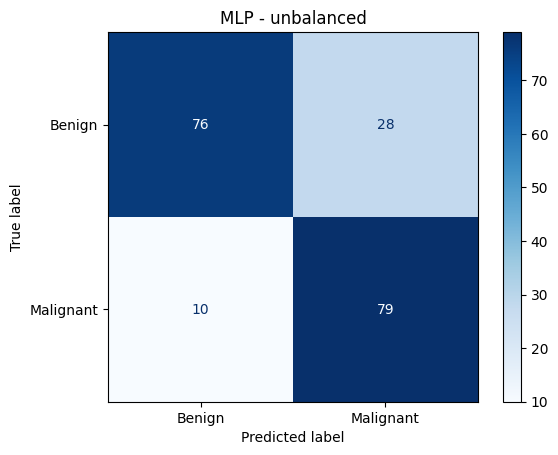

In [388]:
y_pred = mlp_models["unbalanced"].predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Blues")
plt.title(f"MLP - unbalanced")
plt.show()

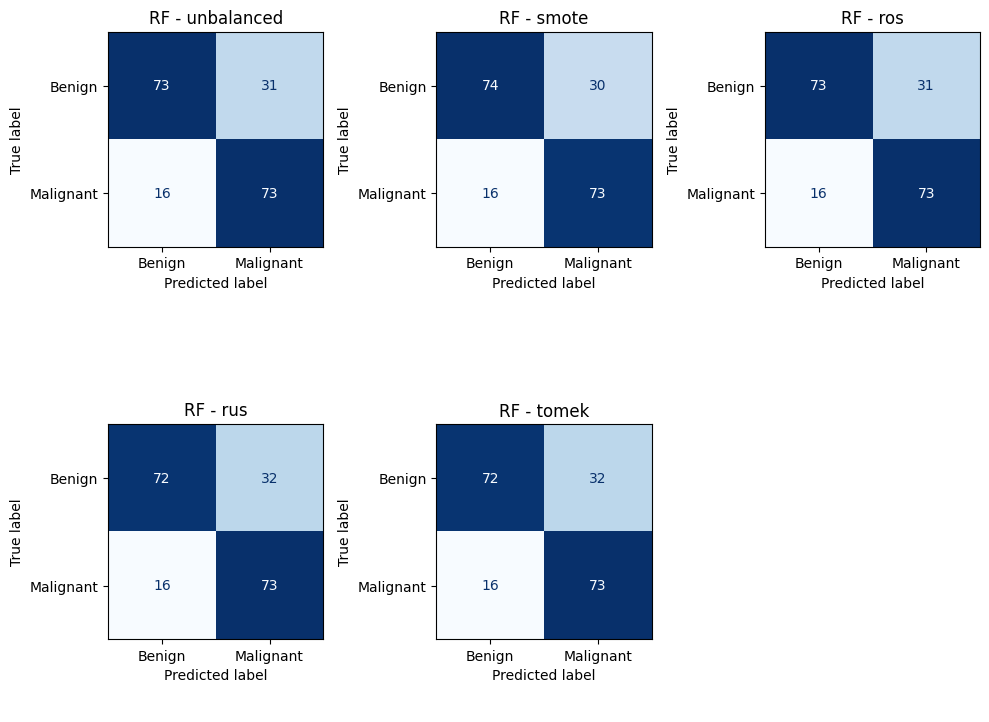

In [389]:
class_labels = ["Benign", "Malignant"]   # Class names shown on the axes

n_cols = 3                                # Number of subplot columns
n_rows = 2                                # Number of subplot rows

# Create a figure with multiple subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()                     # Flatten the axes array for easier iteration

# Plot one confusion matrix for each Random Forest model
for ax, (name, model) in zip(axes, rf_models.items()):
    y_pred = model.predict(X_test)        # Predict class labels on the test set
    cm = confusion_matrix(y_test, y_pred) # Compute the confusion matrix

    # Create and display the confusion matrix in the current subplot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)

    # Set the title of the subplot
    ax.set_title(f"RF - {name}")

# Hide any remaining empty subplots
for ax in axes[len(rf_models):]:
    ax.axis("off")

# Adjust spacing between subplots
plt.tight_layout()

# Show the final figure
plt.show()

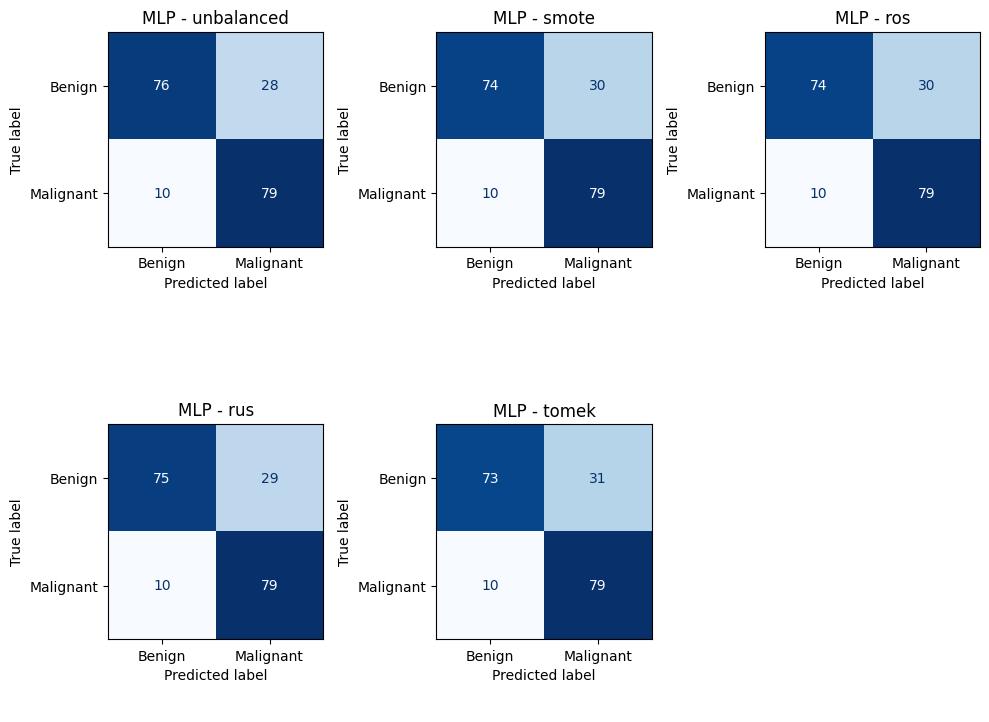

In [390]:
class_labels = ["Benign", "Malignant"]   # Class names shown on the axes

n_cols = 3                                # Number of subplot columns
n_rows = 2                                # Number of subplot rows

# Create a figure with multiple subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()                     # Flatten the axes array for easier iteration

# Plot one confusion matrix for each Random Forest model
for ax, (name, model) in zip(axes, mlp_models.items()):
    y_pred = model.predict(X_test)        # Predict class labels on the test set
    cm = confusion_matrix(y_test, y_pred) # Compute the confusion matrix

    # Create and display the confusion matrix in the current subplot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)

    # Set the title of the subplot
    ax.set_title(f"MLP - {name}")

# Hide any remaining empty subplots
for ax in axes[len(mlp_models):]:
    ax.axis("off")

# Adjust spacing between subplots
plt.tight_layout()

# Show the final figure
plt.show()